# 马尔可夫决策过程
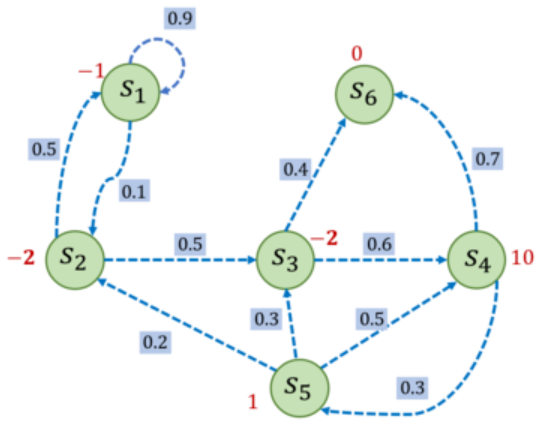

## 简介
马尔可夫决策过程 (Markov Reward Process) 是强化学习的基础。要学习好强化学习我们首先得明确掌握马尔可夫决策过程的基础知识。我们通常说的强化学习中的环境一般就是一个马尔可夫决策过程。与多臂老虎机不同，马尔可夫决策过程包含了状态信息以及状态之间的转移机制。如果我们要用强化学习去解决一个实际问题，我们第一步要做的事情就是能够把这个实际问题抽象为一个马尔可夫决策过程，也就是明确马尔可夫决策过程的各个组成要素。在本节内容中，我们将从马尔可夫过程出发，一步一步进行介绍，最后引出马尔可夫决策过程。

## 马尔可夫奖励过程（Markov Reward Process）
<img alt="image.png" src="attachment:ec85e512-f268-447a-aa0c-8a8c51cd3c97.png"/>
接下来我们将图中马尔可夫奖励过程用代码表示，并且定义计算回报的函数。

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# 导包
import numpy as np

np.random.seed(0)       # 固定随机种子

# 定义状态转移概率矩阵P
P = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
P = np.array(P)

rewards = [-1, -2, -2, 10, 1, 0]        # 定义奖励函数
gamma = 0.5         # 定义折扣因子
# 给定一条序列，计算从某个索引开始到序列最后得到的回报
# 参1：起始时间步索引；参2：状态/节点序列；参3：折扣因子
def compute_return(start_index, chain, gamma):
    """
    start_index: 起始时间步索引
    chain: 状态/节点序列 (例如 [1, 2, 3])
    rewards: 奖励列表 (索引与 chain 中的节点编号对应，例如 rewards[0] 对应节点1)
    gamma: 折扣因子
    """
    G = 0
    # 从后往前遍历，利用 G_t = R_{t+1} + gamma * G_{t+1} 的递推关系
    for i in reversed(range(start_index, len(chain))):
        G = gamma * G + rewards[chain[i] - 1]
    return G

In [2]:
# 一个状态序列：s1-s2-s3-s6
chain = [1, 2, 3, 6]
start_index = 0
G = compute_return(start_index, chain, gamma)
"""
展开计算过程：
    遍历1：i = 3, G03 = 0, G03 = gamma * G03 + rewards[chain[3] - 1] = 0 + rewards[6 - 1] = rewards[5] = 0
    遍历2：i = 2, G03 = 0, G03 = gamma * G03 + rewards[chain[2] - 1] = 0 + rewards[3 - 1] = rewards[2] = -2
    遍历3：i = 1, G03 = -2, G03 = gamma * G03 + rewards[chain[1] - 1] = 0.5 * (-2) + rewards[2 - 1] = -1 + rewards[1] = -1 + -2 = -3
    遍历4：i = 0, G03 = -3, G03 = gamma * G03 + rewards[chain[0] - 1] = 0.5 * (-3) + rewards[1 - 1] = -1.5 + rewards[0] = -1.5 + -1 = -2.5
"""
print("根据本序列（s1-s2-s3-s6）计算得到回报为：", G)

根据本序列（s1-s2-s3-s6）计算得到回报为： -2.5


## 价值函数（Value Function）
我们接下来将求解价值函数的解析解方法用代码写出来，并据此计算上图MRP中所有状态的价值。

In [6]:
# 参1：状态转移概率矩阵P；参2：奖励函数；参3：折扣因子；参4：状态数
def compute(P, rewards, gamma, states_num):
    """
    利用贝尔曼方差矩阵形式计算解析解，states_num是MRP的状态数
    在 MRP 中，状态价值的贝尔曼方程是：
    V = R + γPV
        V：状态价值向量（列向量）
        R：即时奖励向量
        P：状态转移概率矩阵
        γ：折扣因子

    np.eye(states_num, states_num)：生成单位矩阵
    np.linalg.inv(...)：求逆矩阵
    np.dot(...)：矩阵乘法。
    """
    rewards = np.array(rewards).reshape((-1, 1))        # 将rewards写成列向量形式
    value = np.dot(np.linalg.inv(np.eye(states_num, states_num) - gamma * P), rewards)      # 矩阵求逆与乘法计算价值
    # A = np.eye(states_num) - gamma * P
    # value = np.linalg.solve(A, rewards)           # 用 solve 直接解方程 A * V = rewards，替代求逆再相乘
    return value

V = compute(P, rewards, gamma, 6)
print("MRP中每个状态价值分别为：\n", V)

MRP中每个状态价值分别为：
 [[-2.01950168]
 [-2.21451846]
 [ 1.16142785]
 [10.53809283]
 [ 3.58728554]
 [ 0.        ]]


可以自行验证其他状态时候的贝尔曼方程是否也成立。若对于所有状态都成立，就可以说明我们求解得到的价值函数是正确的。马尔可夫奖励过程中的价值函数也可以通过蒙特卡洛的方法估计得到，我们将在本节课程接下来的马尔可夫决策过程中进行介绍该方法。

## 马尔可夫决策过程（Markov Decision Process）
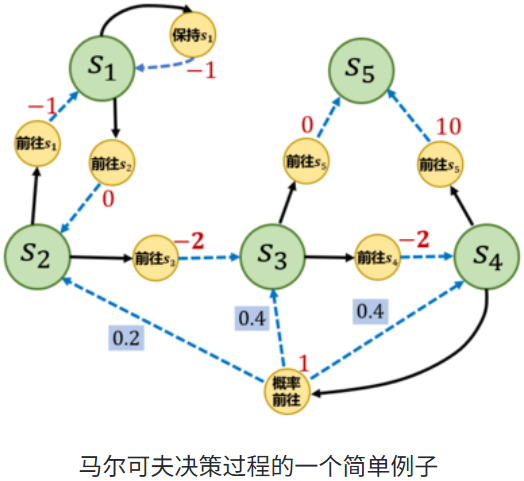
接下来我们将图中马尔可夫决策过程用代码表示，并且定义两个策略。第一个策略是一个随机策略，即在每个状态的时候，会以同样的概率选取它可能采取的动作，例如在s_1会以0.5和0.5概率选取动作“保持s_1”和“前往s_2”。第二个策略是一个我们提前设定的一个策略。

In [16]:
S = ["S1", "S2", "S3", "S4", "S5"]         # 状态State集合
A = ["保持S1", "前往S1", "前往S2", "前往S3", "前往S4", "前往S5", "概率前往"]        # 动作集合
# 状态转移函数
P = {
    "S1-保持S1-S1":1.0, "S1-前往S2-S2":1.0,
    "S2-前往S1-S1":1.0, "S2-前往S3-S3":1.0,
    "S3-前往S4-S4":1.0, "S3-前往S5-S5":1.0,
    "S4-前往S5-S5":1.0, "S4-概率前往-S2":0.2,
    "S4-概率前往-S3":0.4, "S4-概率前往-S4":0.4
}

# 奖励函数
R = {
    "S1-保持S1":-1, "S1-前往S2":0,
    "S2-前往S1":-1, "S2-前往S3":-2,
    "S3-前往S4":-2, "S3-前往S5":0,
    "S4-前往S5":10, "S4-概率前往":1
}

# 折扣因子
gamma = 0.5
MDP = (S, A, P, R, gamma)       # MDP五元组：(状态State, 动作Action, 状态转移函数P, 奖励函数R, 折扣因子γ)

# 策略1：随机策略
Pi_1 = {
    "S1-保持S1":0.5, "S1-前往S2":0.5,
    "S2-前往S1":0.5, "S2-前往S3":0.5,
    "S3-前往S4":0.5, "S3-前往S5":0.5,
    "S4-前往S5":0.5, "S4-概率前往":0.5
}

# 策略2
Pi_2 = {
    "S1-保持S1":0.6, "S1-前往S2":0.4,
    "S2-前往S1":0.3, "S2-前往S3":0.7,
    "S3-前往S4":0.5, "S3-前往S5":0.5,
    "S4-前往S5":0.1, "S4-概率前往":0.9
}

# 把输入的两个字符串通过 "-" 连接，便于我们使用上述定义的P，R变量
def join(str1, str2):
    return str1 + '-' + str2

我们现在就用代码实现来用该方法计算用随机策略（即Pi_1）时的状态价值函数。为了简单起见，我们直接给出转化后的MRP的状态转移矩阵的奖励函数，可自行验证。

In [17]:
gamma = 0.5
# 策略1转化后的MRP的状态转移矩阵
P_from_mdp_to_mrp = [
    [0.5, 0.5, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.5, 0.5],
    [0.0, 0.1, 0.2, 0.2, 0.5],
    [0.0, 0.0, 0.0, 0.0, 1.0]
]

P_from_mdp_to_mrp = np.array(P_from_mdp_to_mrp)
R_from_mdp_to_mrp = [-0.5, -1.5, -1.0, 5.5, 0]

V = compute(P_from_mdp_to_mrp, R_from_mdp_to_mrp, gamma, 5)
print("MRP中每个状态价值分别为：\n", V)

MRP中每个状态价值分别为：
 [[-1.22555411]
 [-1.67666232]
 [ 0.51890482]
 [ 6.0756193 ]
 [ 0.        ]]


接下来用动态规划的方法来计算得到价值函数。首先介绍用蒙特卡洛方法来近似估计这个价值函数，用蒙特卡洛方法的好处在于我们不需要知道MDP的状态转移函数和奖励函数，但是它只能得到一个近似值，并且采样数越多越准确。

## 蒙特卡洛方法（Monte-Carlo methods）
接下来我们用代码定义一个采样函数，需要遵守状态转移矩阵和相应的策略，我们每次将(s, a, r, s_next)元组放入序列中，直到到达终止序列。然后我们通过该函数实现用随机策略在图中MDP实际采样几条序列。

In [19]:
# 参1：MDP五元组；参2：策略；参3：最长时间步；参4：采样序列数
def sample(MDP, Pi, timestep_max, number):
    S, A, P, R, gamma = MDP
    episodes = []
    for _ in range(number):         # 采样number次
        episode = []
        timestep = 0
        s = S[np.random.randint(4)]     # 随机选择一个除了s5以外的状态s作为起点
        while s != "S5" and timestep <= timestep_max:       # 当前状态为终止状态或者时间步太长时，一次采样结束
            timestep += 1
            rand, temp = np.random.rand(), 0
            # 在状态s根据策略选择动作
            for a_opt in A:
                temp += Pi.get(join(s, a_opt), 0)
                if temp > rand:
                    a = a_opt
                    r = R.get(join(s, a), 0)
                    break
            rand, temp = np.random.rand(), 0
            # 根据状态转移概率得到下一个状态s_next
            for s_opt in S:
                temp += P.get(join(join(s, a), s_opt), 0)
                if temp > rand:
                    s_next = s_opt
                    break
            episode.append((s, a, r ,s_next))       # 把(s, a, r ,s_next)元组放入序列中
            s = s_next      # s_next变成当前状态，开始接下来的循环
        episodes.append(episode)
    return episodes

# 采样5次，每个序列最长不超过1000步
episodes = sample(MDP, Pi_1, 20, 5)
print("第一条序列", episodes[0])
print("第二条序列", episodes[1])
# print("第三条序列", episodes[2])
# print("第四条序列", episodes[3])
print("第五条序列", episodes[4])

第一条序列 [('S1', '保持S1', -1, 'S1'), ('S1', '保持S1', -1, 'S1'), ('S1', '前往S2', 0, 'S2'), ('S2', '前往S3', -2, 'S3'), ('S3', '前往S4', -2, 'S4'), ('S4', '概率前往', 1, 'S4'), ('S4', '前往S5', 10, 'S5')]
第二条序列 [('S3', '前往S5', 0, 'S5')]
第五条序列 [('S2', '前往S3', -2, 'S3'), ('S3', '前往S5', 0, 'S5')]


In [20]:
# 对所有采样序列计算所有状态的价值
# 参1：采样序列；参2：状态价值函数；参3：访问次数；参4：折扣因子γ
def MC(episodes, V, N, gamma):
    for episode in episodes:
        G = 0
        for i in range(len(episode) - 1, -1, -1):       # 一个序列从后往前计算
            (s, a, r, s_next) = episode[i]
            G = r + gamma * G
            N[s] += 1
            V[s] += (G - V[s]) / N[s]

timestep_max = 20
episodes = sample(MDP, Pi_1, timestep_max, 1000)        # 采样1000次
gamma = 0.5
V = {"S1":0, "S2":0, "S3":0, "S4":0, "S5":0}
N = {"S1":0, "S2":0, "S3":0, "S4":0, "S5":0}
MC(episodes, V, N, gamma)
print("使用蒙特卡洛法计算MDP状态价值为：\n", V)

使用蒙特卡洛法计算MDP状态价值为：
 {'S1': -1.2107031925151632, 'S2': -1.6727288363409811, 'S3': 0.5290777791735056, 'S4': 6.064861783381983, 'S5': 0}


可以看到使用蒙特卡洛方法估计得到的状态价值，和我们用MRP解析解得到的状态价值是很接近的。这当然得益于我们采样了比较多的序列，可以尝试一下修改采样次数，然后观察蒙特卡洛方法的结果

## 占用度量（Occupancy Measure）
接下来我们用代码来近似估计度量函数。这里我们采用近似估计，设置一个较大的episode length最大值，然后采样很多次，用(s, a)组出现的频率估计实际概率。

In [22]:
# 参1：采样序列；参2：状态s；参3：动作a；参4：最大时间步；参5：折扣因子γ
def occupancy(episodes, s, a, timestep_max, gamma):
    """计算状态-动作对(s, a)出现的频率，以此来估算策略的占用度量"""
    rho = 0         # 记录总得分（奖励？）
    total_times = np.zeros(timestep_max)        # 记录每个时间步t各被经历过几次（类似于打卡器，记录在第t步，总共有多少条路线走到了这里）
    occur_times = np.zeros(timestep_max)        # 记录(s_t, a_t) = (s, a)的个数（在第t步，恰好触发了(s, a)这个组合的次数）
    for episode in episodes:                    # 把采样出来的 1000 条路线，一条一条拿出来看
        for i in range(len(episode)):           # 对于当前这条路线，从第0步一直看到它结束的最后一个时间步
            (s_opt, a_opt, r ,s_next) = episode[i]    # 把这条路线在第i步的记录拆开，即状态s_opt、动作a_opt、奖励r、下一步s_next
            total_times[i] += 1             # 既然有路线走到了第i步，那就给第i步的total_times打卡器加 1
            if s == s_opt and a == a_opt:       # 看看当前状态s_opt和动作a_opt，是不是我们正在找的目标
                occur_times[i] += 1     # 如果是，就给第i步的 occur_times打卡器加1
    for i in reversed(range(timestep_max)):
        if total_times[i]:              # 如果根本没路线走到第i步，就不看了
            rho += gamma ** i * occur_times[i] / total_times[i]
            """
            occur_times[i] / total_times[i]：算出在第 i 步，发生目标动作的条件概率。比如走到第 5 步的路线有 100 条，其中 30 条触发了 (S4, 概率前往)，那概率就是 30/100 = 0.3。
            gamma ** i：给这个概率打个折扣。第 0 步的概率乘 1，第 1 步乘 0.5，第 2 步乘 0.25……越往后越不值钱。
            rho += ...：把每一步算出来的折扣概率加起来，存进小本本里。
            """
    # 最后乘上(1 - gamma)（即 1 - 0.5 = 0.5），对结果做一个归一化。这是为了让它变成一个真正的概率分布（总和为 1），这就叫"归一化占用度量"
    return (1 - gamma) * rho

In [23]:
gamma = 0.5
timestep_max = 1000

episodes_1 = sample(MDP, Pi_1, timestep_max, 1000)      # 按照策略 Pi_1（随机策略）
episodes_2 = sample(MDP, Pi_2, timestep_max, 1000)      # 按照策略 Pi_2（偏向策略）

# 计算在随机策略Pi_1下，智能体到底有多大比例的时间是在 S4 做 "概率前往"
rho_1 = occupancy(episodes_1, "S4", "概率前往", timestep_max, gamma)
# 计算在偏向策略Pi_2下，智能体到底有多大比例的时间是在 S4 做 "概率前往"
rho_2 = occupancy(episodes_2, "S4", "概率前往", timestep_max, gamma)

# rho_2 远大于 rho_1，因为：
# Pi_1 是随机策略，在 S4 时，选 "前往S5" 和 "概率前往" 的概率各是 0.5。
# Pi_2 是偏向策略，在 S4 时，选 "概率前往" 的概率高达 0.9。
print(rho_1)
print(rho_2)


0.12183000443742306
0.22885736405206852


## 总结
在本章内容中，我们从零开始学习了马尔可夫决策过程（即MDP）的一些基础概念知识，以及如何用求解贝尔曼方程得到状态价值的解析解和用蒙特卡罗方法估计各个状态的价值。马尔可夫决策过程是强化学习的基础，之后学习的强化学习方法通常都是在求解马尔可夫决策过程中的最优策略。即强化学习中的环境就是一个马尔可夫决策过程。